In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import dijet
import random
from IPython.display import display, Math

# setup plotting
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.labelsize"] = 25  
plt.rcParams["xtick.labelsize"] = 20  
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 18  
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
%config InlineBackend.figure_format = 'retina'
plt.rcParams['axes.xmargin'] = 0.00

In [26]:
pT_values = np.linspace(0.5, 20, 100)

dq = 0.05/np.sqrt(3/(2*np.pi))
nsteps = round(np.log(100)/dq)
qs = np.linspace(0, np.log(100), nsteps)

# Q_values = np.sqrt(np.exp(qs))
Q_values = np.linspace(0.5, 10, 20)
print(Q_values)

fb_kins = dijet.Kinematics(z=0.5, x=0.01)

pT_grid = np.zeros((100, nsteps))
Q_grid = np.zeros((100, nsteps))

models = ['gauss']
model_values = {
    'gauss': [[0.0], [0.5], [1.0], [1.5]]
}

djs = {mod: [] for mod in models}
for mod in models:
    for value in model_values[mod]:
        djs[mod].append(dijet.DIJET(constrained_moments=True, fit_type='pp', IR_reg=[mod,*value], lambdaIR=0.4))

fb_values = {mod: [] for mod in models}
for mod in models:
    for iv in range(len(djs[mod])):
        print(mod, iv)
        fb_values_tmp = {}
        amps = ['N', 'Qu', 'Qd', 'Qs', 'G2', 'I3u', 'I3d', 'I3s', 'I4', 'I5']
        for amp in amps: fb_values_tmp[amp] = np.zeros((100, nsteps))
        
        for i, pT in enumerate(pT_values):
            for j, Q in enumerate(Q_values):
        
                pT_grid[i,j] = pT
                Q_grid[i,j] = Q*np.sqrt(0.5*(1-0.5))
        
                fb_kins.pT = pT
                fb_kins.Q = Q

                # print(np.log(((Q**2)/(fb_kins.x))/1.0))
        
                for amp in amps:
                    if amp == 'N': fb_values_tmp[amp][i,j] = djs[mod][iv].fourier_bessel(fb_kins, [[1,1,0,0]], amp)
                    else: fb_values_tmp[amp][i,j] = djs[mod][iv].fourier_bessel(fb_kins, [[1,1,0,0]], amp)

        fb_values[mod].append(fb_values_tmp)
        

[ 0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.
  7.5  8.   8.5  9.   9.5 10. ]
--> !!! Using constrained moment parameters!
--> loaded replica 1
--> !!! Using constrained moment parameters!
--> loaded replica 1
--> !!! Using constrained moment parameters!
--> loaded replica 1
--> !!! Using constrained moment parameters!
--> loaded replica 1
gauss 0
gauss 1
gauss 2
gauss 3


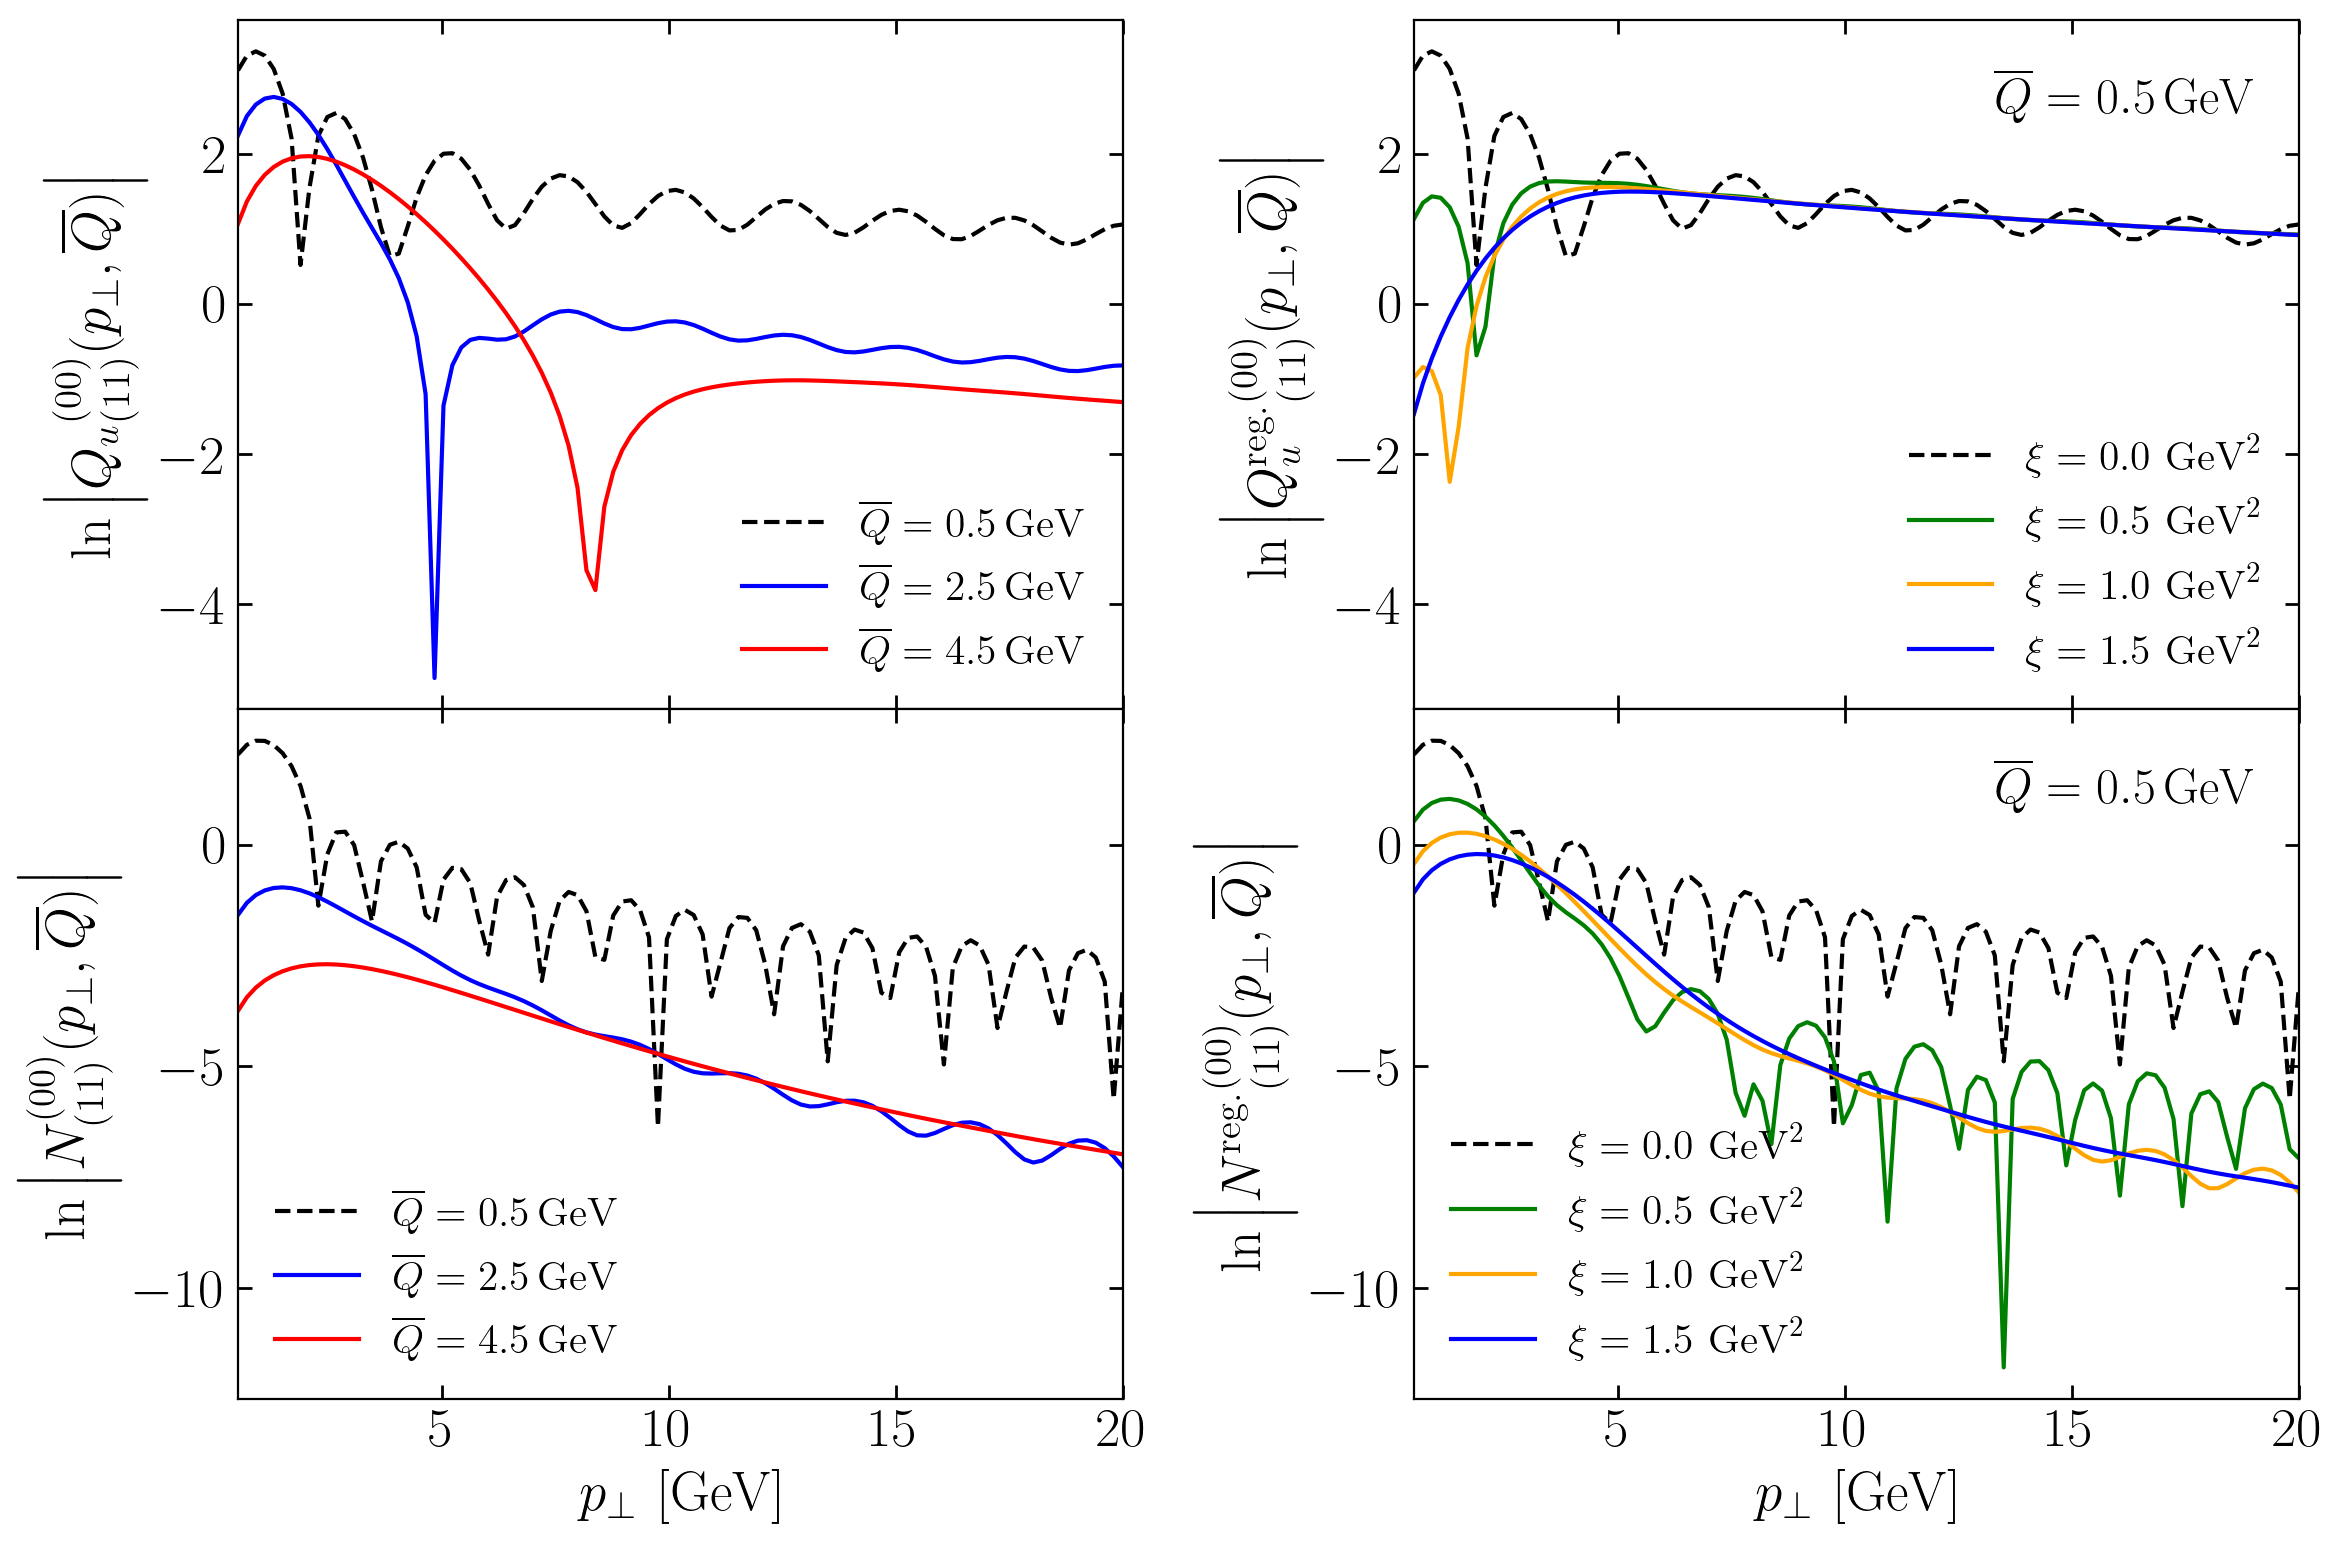

In [33]:
# plot
asp_ratio = 4.5/3
psize = 4
nrows, ncols = 2,2
fig, ax = plt.subplots(nrows, ncols, figsize=(asp_ratio*psize*ncols, psize*nrows), sharey='row', sharex='col')

Qcolors = ['black', 'blue', 'red']
xicolors = ['black', 'green', 'orange', 'blue']
linestyles = ['--','-','-', '-']
amp_strs = {
    'N': 'N',
    'Qu': 'Q_u', 'Qd': 'Q_d', 'Qs':'Q_s', 'G2':'G_2', 'I3u':'I_{{3u}}', 
    'I3d':'I_{{3d}}', 'I3s':'I_{{3s}}', 'I4':'I_{{4}}', 'I5':'I_{{5}}'
    }

amp = 'Qu' 
for iQ, j in enumerate([1,9,17]):
    ax[0,0].plot(pT_grid[:,0], np.log(np.abs(fb_values['gauss'][0][amp][:,j])), 
               color=Qcolors[iQ], 
               label=rf'$\overline Q =  {round(Q_grid[0, j], 2)} \, \mathrm{{GeV}}$',
                linestyle=linestyles[iQ]
                ) 

for ixi, xi in enumerate(model_values['gauss']):
    ax[0,1].plot(pT_grid[:,0], np.log(np.abs(fb_values['gauss'][ixi][amp][:, 1])), 
               color=xicolors[ixi],
               label = fr'$\xi = {xi[0]}\,\, \mathrm{{GeV}}^{{2}}$',
                 linestyle=linestyles[ixi]
                )


ax[0,0].set_ylabel(fr'$\ln\Big|{{{amp_strs[amp]}}}_{{(11)}}^{{(00)}} (p_{{\perp}}, \overline{{Q}})\Big|$', size=20)
ax[0,1].set_ylabel(fr'$\ln\Big|{{{amp_strs[amp]}^{{\mathrm{{reg.}}}}}}_{{(11)}}^{{(00)}} (p_{{\perp}}, \overline{{Q}})\Big|$', size=20)


amp = 'N' 
for iQ, j in enumerate([1,9,17]):
    ax[1,0].plot(pT_grid[:,0], np.log(np.abs(fb_values['gauss'][0][amp][:,j])), 
               color=Qcolors[iQ], 
               label=rf'$\overline Q =  {round(Q_grid[0, j], 2)} \, \mathrm{{GeV}}$',
                 linestyle=linestyles[iQ]
                ) 

for ixi, xi in enumerate(model_values['gauss']):
    ax[1,1].plot(pT_grid[:,0], np.log(np.abs(fb_values['gauss'][ixi][amp][:, 1])), 
               color=xicolors[ixi], 
               label = fr'$\xi = {xi[0]}\,\, \mathrm{{GeV}}^{{2}}$',
                 linestyle=linestyles[ixi]
                 )
    


ax[1,0].set_ylabel(fr'$\ln\Big|{{{amp_strs[amp]}}}_{{(11)}}^{{(00)}} (p_{{\perp}}, \overline{{Q}})\Big|$', size=20)
ax[1,1].set_ylabel(fr'$\ln\Big|{{{amp_strs[amp]}^{{\mathrm{{reg.}}}}}}_{{(11)}}^{{(00)}} (p_{{\perp}}, \overline{{Q}})\Big|$', size=20)

for i in range(2):
    for j in range(2):
        if i==1:
            ax[i,j].set_xlabel(r'$p_\perp \,\,[\mathrm{GeV}]$', size=20)
        ax[i,j].legend(frameon=False, fontsize=15)
        ax[i,j].tick_params(axis="both", direction="in", length=5, width=1, which='both', right=True, top=True)

        ax[i,j].tick_params(labelleft=True)

    ax[i,1].text(
            0.95, 0.85, fr'$\overline{{Q}} = {Q_grid[0, 1]}\, \mathrm{{GeV}}$', 
            transform=ax[i,1].transAxes,
            ha='right', va='bottom', 
            fontsize=18, wrap=True, 
            color='black'
    )


plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()


# fig.savefig('plots/fb_oscillation.pdf', dpi=500)

In [32]:
harmonics = ['1', 'cos(phi_kp)', 'cos(phi_Dp)', 'cos(phi_Dp)cos(phi_kp)', 'sin(phi_Dp)sin(phi_kp)']

pT_values = np.linspace(0.5, 10, 50)

roots = 50
space = {
    'y': [0.05, 0.95],
    't': 0.1,
    'Q2': [1, 100],
    'z': [0.2, 0.5],
    'phi_Dp': [0, 2*np.pi],
    'phi_kp': [0, 2*np.pi]
}
npoints = 4
r0 = 0.5


dsaharms = {}
for mod in models:
    dsaharms[mod] = {}
    for iv, value in enumerate(model_values[mod]):
        value = value
        print(mod, value)
        dsaharms[mod][iv] = {}

        denom = djs[mod][iv].get_integrated_xsec(
            pT_values, roots**2, space, points=npoints, kind='den', r0=r0
        )
        for harm in harmonics:
            dsaharms[mod][iv][f'<{harm}>'] = djs[mod][iv].get_integrated_xsec(
                pT_values, roots**2, space, weight=harm, points=npoints, kind='num', r0=r0
            ) / denom

gauss [0.0]
gauss [0.5]
gauss [1.0]
gauss [1.5]


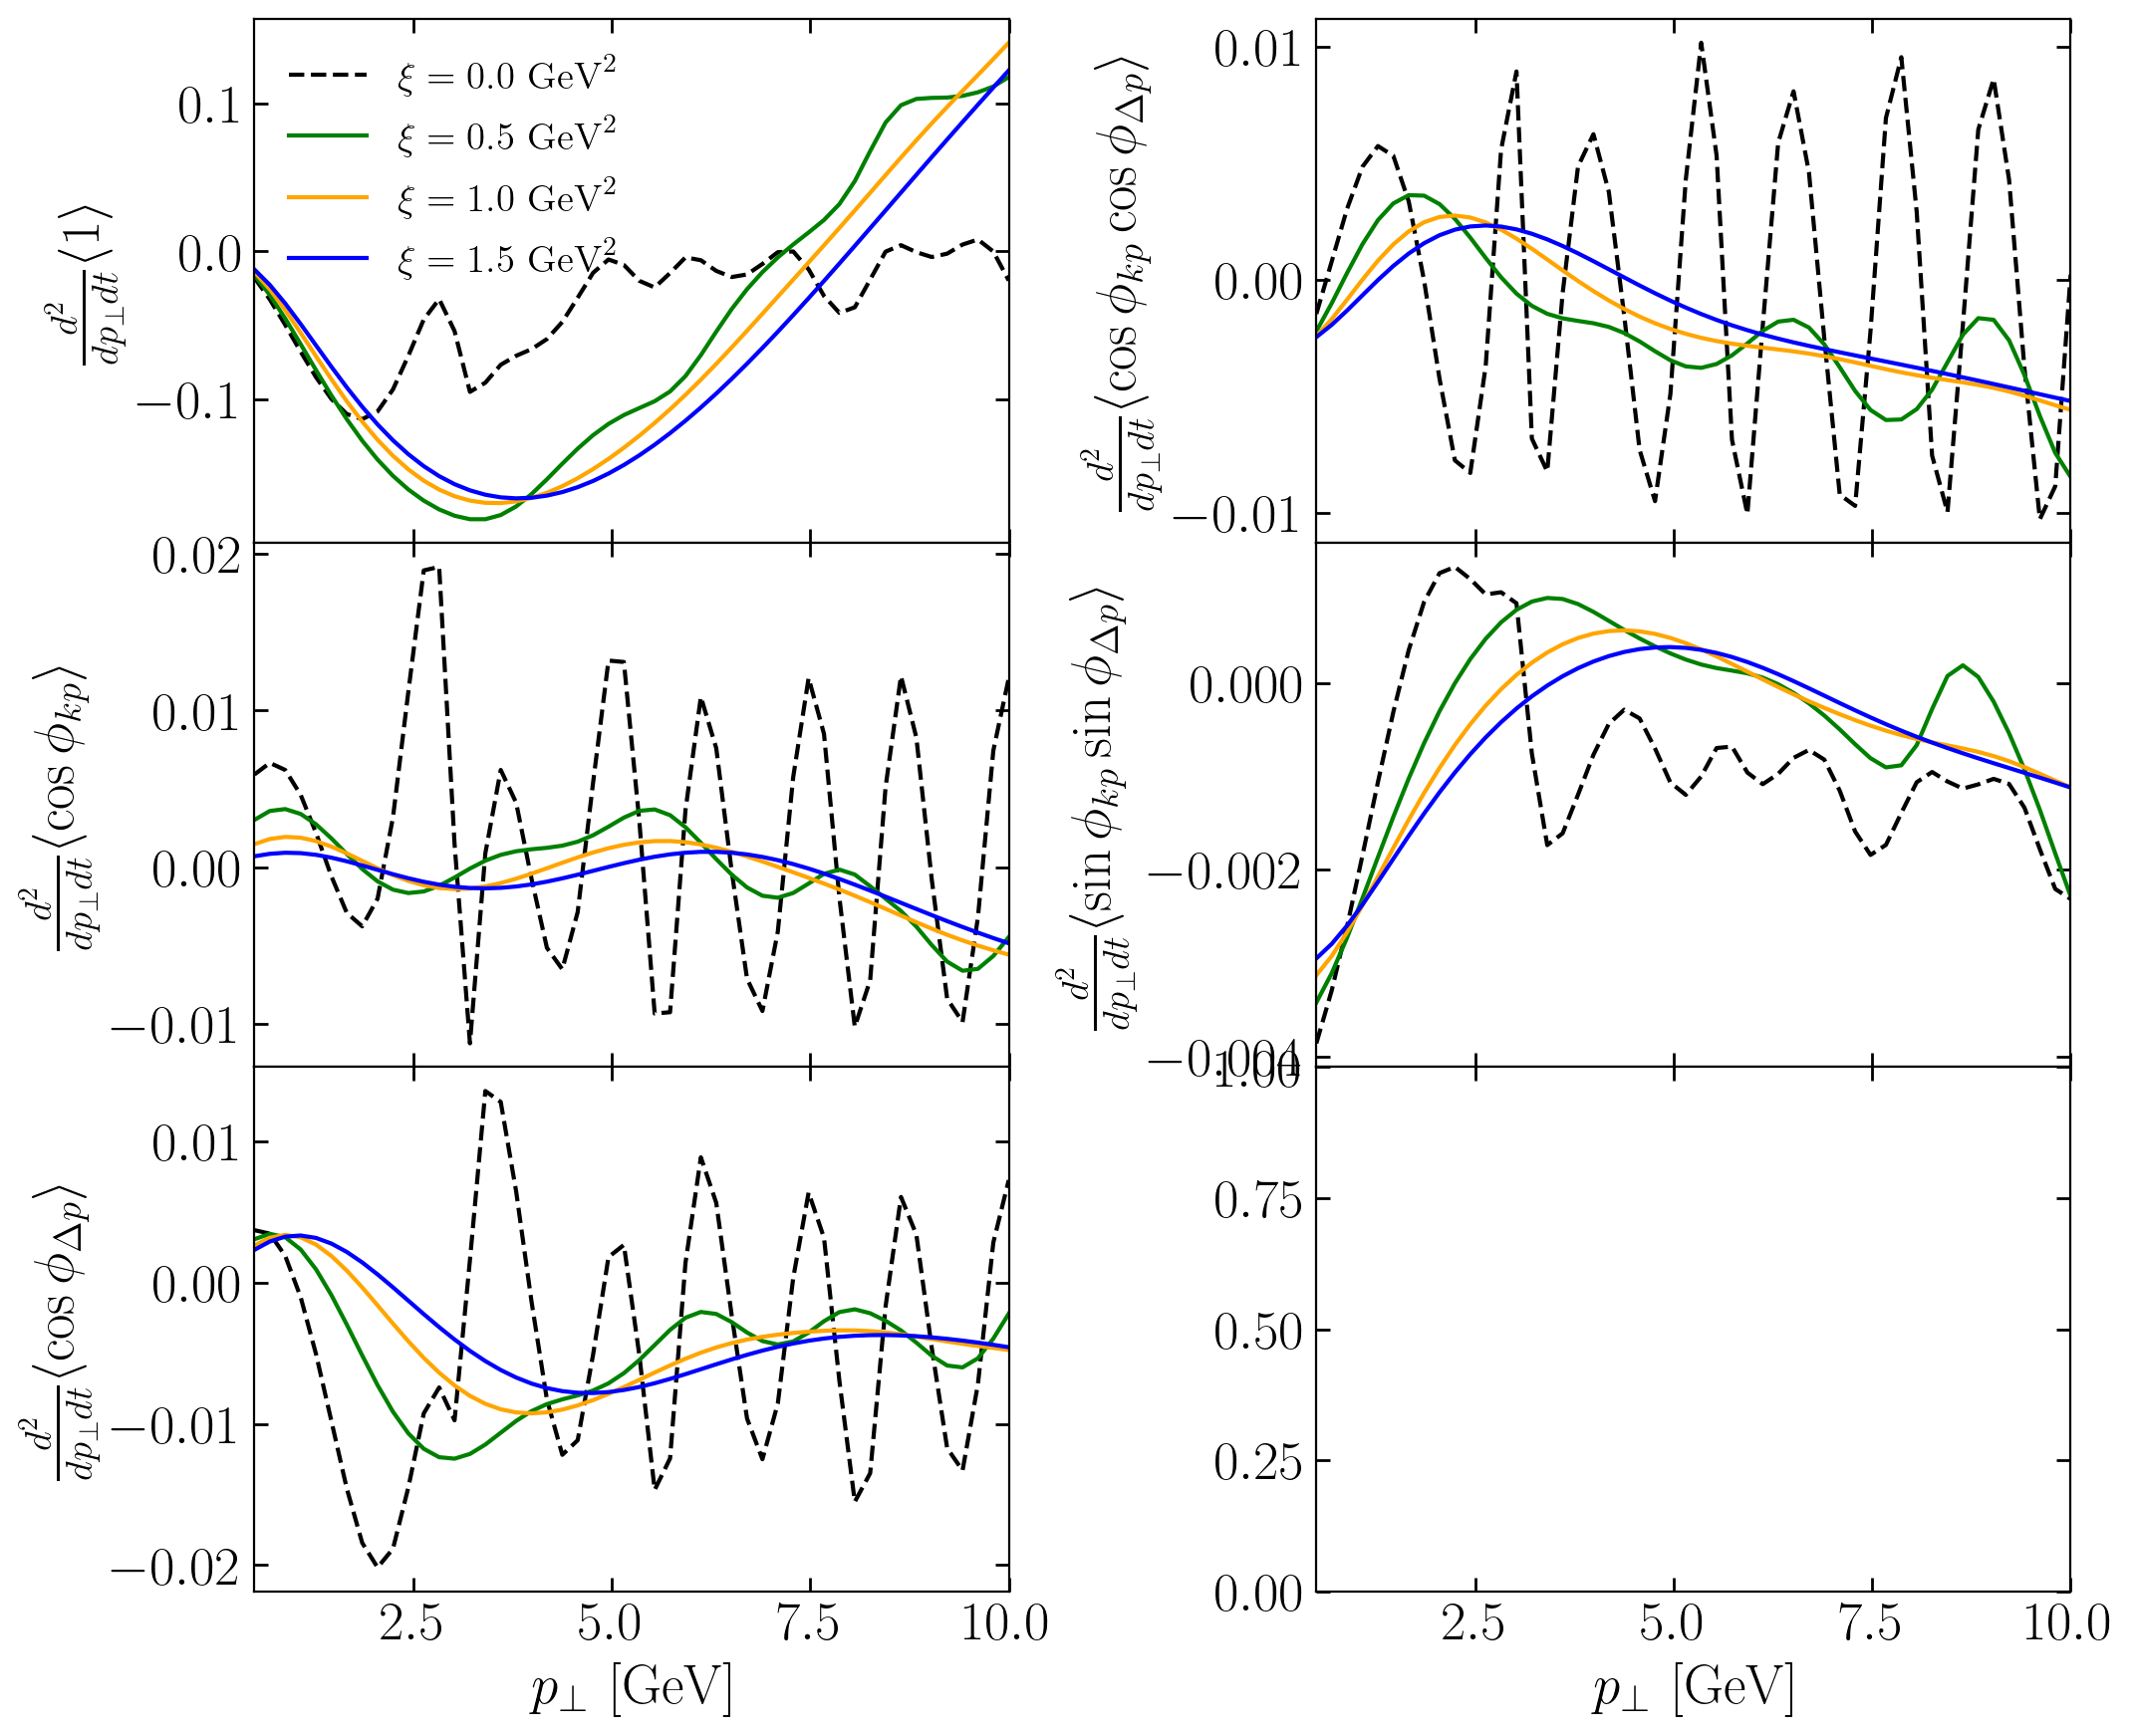

In [58]:
# plot
asp_ratio = 5.5/3
psize = 3
nrows, ncols = 3,2
fig, ax = plt.subplots(nrows, ncols, figsize=(asp_ratio*psize*ncols, psize*nrows), sharex='col')
axs = [ax[ir, ic] for ic in range(ncols) for ir in range(nrows)]

xicolors = ['black', 'green', 'orange', 'blue']
linestyles = ['--','-','-', '-']

for ih, harm in enumerate(harmonics):
    for ixi, xi in enumerate(model_values['gauss']):
        axs[ih].plot(pT_values, dsaharms['gauss'][ixi][f'<{harm}>'], 
                color=xicolors[ixi],
                label = fr'$\xi = {xi[0]}\,\, \mathrm{{GeV}}^{{2}}$',
                    linestyle=linestyles[ixi]
                )


axs[0].set_ylabel(r'$ \frac{ d^2 }{ d p_{\perp} dt } \langle 1 \rangle $', size=20)
axs[1].set_ylabel(r'$ \frac{ d^2 }{ d p_{\perp} dt } \langle \cos \phi_{k p} \rangle $', size=20)
axs[2].set_ylabel(r'$ \frac{ d^2 }{ d p_{\perp} dt } \langle \cos \phi_{\Delta p} \rangle $', size=20)
axs[3].set_ylabel(r'$ \frac{ d^2 }{ d p_{\perp} dt } \langle \cos \phi_{k p} \cos \phi_{\Delta p} \rangle $', size=20)
axs[4].set_ylabel(r'$ \frac{ d^2 }{ d p_{\perp} dt } \langle \sin \phi_{k p} \sin \phi_{\Delta p} \rangle $', size=20)

for i in range(len(axs)):
    axs[i].set_xlabel(r'$p_\perp \,\,[\mathrm{GeV}]$', size=20)
    axs[0].legend(frameon=False, fontsize=14)
    axs[i].tick_params(axis="both", direction="in", length=5, width=1, which='both', right=True, top=True, labelleft=True)

# info = r'''
# $t=0.1 \, \mathrm{GeV}^2$
# $y\in[0.05, 0.95]$
# $z\in[0.2, 0.5]$
# $Q^2 \in [1, 100] \, \mathrm{GeV}^2$
# '''
# ax[0].text(
#         0.68, -0.01, info, 
#         transform=ax[0].transAxes,
#         ha='left', va='bottom', 
#         fontsize=15, wrap=True, 
#         color='black'
# )


plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()


# fig.savefig('plots/dsa_regulator_variation.pdf', dpi=500)